In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import FuncAnimation

In [8]:
def updatePosition(position, index, operator):
    p = list(position)
    if operator:
        p[index] += 1
        position = tuple(p)
    else:
        p[index] -= 1
        position = tuple(p)
    return position


def setSpace(size):
    # size of the space will be size ** 2
    space = {}
    for w in range(size):
        for h in range(size):
            val = random.randint(1, 16)
            if val == 4:
                space[(w, h)] = 'pizza'
            else:
                space[(w, h)] = 0
    w = random.randint(0, (len(space) - 1) // size)
    h = random.randint(0, (len(space) - 1) // size)
    position = (w, h)
    space[w, h] = 'agent'

    return space, position, size


def randomWalk(steps, space, position, size):
    health = 50
    points = 0
    positions = []
    positions.append(position)
    for i in range(steps):
        direction = random.randint(1, 4)
        try:
            if space[position] == 'pizza':
                points += 1
                if health < 50:
                    health += 1
            if direction == 1:
                space[position] = 1
                position = updatePosition(position, 1, True)
            elif direction == 2:
                space[position] = 1
                position = updatePosition(position, 1, False)
            elif direction == 3:
                space[position] = 1
                position = updatePosition(position, 0, True)
            else:
                space[position] = 1
                position = updatePosition(position, 0, False)
        except:
            print('You hit the wall! Ramaining HP is: ' + str(health))
            health -= 1
            if health <= 0:
                print('Game Over!')
                return space, positions, points
        else:
            if position[0] == -1:
                position = updatePosition(position, 0, True)
            elif position[0] == size:
                position = updatePosition(position, 0, False)
            elif position[1] == -1:
                position = updatePosition(position, 1, True)
            elif position[1] == size:
                position = updatePosition(position, 1, False)
                positions.append(position)

    return space, positions, points

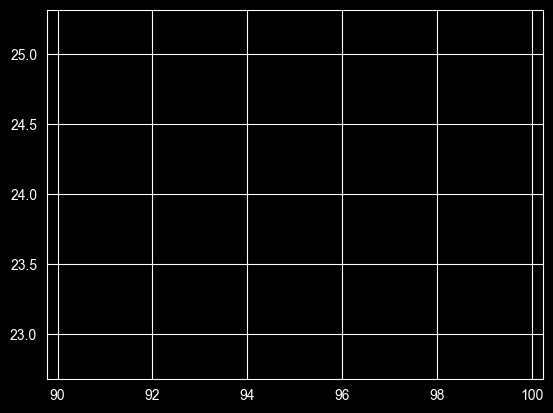

In [9]:
space, position, size = setSpace(100)
space, positions, points = randomWalk(10000, space, position, size)
x = [i[0] for i in positions]
y = [i[1] for i in positions]
# plt.style.use('seaborn')
plt.plot(x, y)
plt.show()

# Q2

In [10]:
import operator
import networkx as nx

G = nx.Graph()
G.add_nodes_from(["John", "Mary", "Jill", "Todd",
                  "iPhone5", "Kindle Fire", "Fitbit Flex Wireless", "Harry Potter", "Hobbit"])
G.add_edges_from([
    ("John", "iPhone5"),
    ("John", "Kindle Fire"),
    ("Mary", "iPhone5"),
    ("Mary", "Kindle Fire"),
    ("Mary", "Fitbit Flex Wireless"),
    ("Jill", "iPhone5"),
    ("Jill", "Kindle Fire"),
    ("Jill", "Fitbit Flex Wireless"),
    ("Todd", "Fitbit Flex Wireless"),
    ("Todd", "Harry Potter"),
    ("Todd", "Hobbit"),
])
pr = nx.pagerank(G)
pr = sorted(pr.items(), key=operator.itemgetter(1), reverse=True)

In [11]:
print("PageRank")
for item, score in pr:
    print(item, score)
print()

PageRank
Todd 0.15917841661548843
Fitbit Flex Wireless 0.1323779298062533
Mary 0.12460876386226832
Jill 0.12460876386226832
iPhone5 0.12429546358018015
Kindle Fire 0.12429546358018015
John 0.08710137671923893
Harry Potter 0.06176691098706105
Hobbit 0.06176691098706105



In [12]:
print("Personalised PageRank")
ppr = nx.pagerank(G, personalization={"John": 1})
ppr = sorted(ppr.items(), key=operator.itemgetter(1), reverse=True)
for item, score in ppr:
    print(item, score)

Personalised PageRank
John 0.24958859145792606
iPhone5 0.17574350840847155
Kindle Fire 0.17574350840847155
Mary 0.12294575662631481
Jill 0.12294575662631481
Fitbit Flex Wireless 0.08243598876216736
Todd 0.04506222962894379
Harry Potter 0.012767330040694894
Hobbit 0.012767330040694894
